[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/probability_statistics/01_sample_spaces_and_probability_axioms/first_principles.ipynb)

# Module 01 — Sample Spaces and Probability Axioms

## 1. Why This Module Exists

Probability is an accounting system for uncertainty. A random experiment — a coin flip, a die roll, a noisy voltage reading — has a set of conceivable outcomes. We cannot predict which outcome occurs, but we *can* demand that our numerical degrees of belief obey consistency rules: beliefs are non-negative, certainty is normalized to 1, and belief in "either of two incompatible things" adds up.

Two older "definitions" of probability fail as foundations.

1. The **classical definition** $\mathbb{P}(A) = \lvert A \rvert / \lvert \Omega \rvert$ presupposes that outcomes are "equally likely" — a probabilistic notion — so it defines probability in terms of itself, and it says nothing at all when $\Omega$ is infinite or asymmetric.
2. The **frequentist definition** $\mathbb{P}(A) = \lim_{n \to \infty} n_A / n$ names a limit that is an empirical hypothesis rather than a mathematical object: no finite record of trials can confirm it, and nothing guarantees the limit exists.

Kolmogorov's 1933 axiomatization inverts the logic. Three axioms *define* what a probability measure is; long-run frequency then becomes a **theorem** (the law of large numbers) rather than a definition, and the classical rule becomes a **modeling choice** justified by symmetry. Everything downstream — conditional probability, random variables, limit theorems, Bayesian inference — is derived from the single triple $(\Omega, \mathcal{F}, \mathbb{P})$.

For machine learning this is not decoration. A language model's next-token distribution is a probability measure on a finite sample space of vocabulary items; a generative model defines a measure on image space; PAC-learning guarantees are Boole's inequality applied to failure events. Every one of those uses rules — complement, monotonicity, inclusion–exclusion, the union bound, continuity — that this module proves from the three axioms and nothing else.

## 2. Intuition

Think of $\mathbb{P}$ as **area**, normalized so that the whole board has area 1.

- Area is never negative. *(Axiom 1)*
- The whole board has area 1. *(Axiom 2)*
- Non-overlapping regions have areas that add. *(Axiom 3)*

Every rule in this module is what that picture forces. Monotonicity is "a region inside another region cannot have more area". Inclusion–exclusion is "if you add two overlapping areas you counted the overlap twice, so subtract it once". The union bound is "if you add the areas of overlapping regions you can only overshoot the area of their union, never undershoot it".

The union bound deserves its own picture, because its proof is a geometric move rather than an algebraic one. Given regions $A_1, A_2, A_3, \ldots$ that overlap arbitrarily, **carve** them:

$$
B_1 = A_1, \qquad B_i = A_i \setminus \bigl(A_1 \cup \cdots \cup A_{i-1}\bigr).
$$

Each point of the union is awarded to the *first* region that contains it. The $B_i$ are disjoint by construction, they cover exactly the same union, and $B_i \subseteq A_i$. So additivity applies to the $B_i$, and monotonicity replaces each $\mathbb{P}(B_i)$ by the larger $\mathbb{P}(A_i)$. That is the entire proof, and the figure below shows it as a picture: shaded by owner, the three discs tile their union without double counting.

Countable — not merely finite — additivity is the one axiom whose necessity is invisible in the area picture. Finite additivity handles any fixed number of regions; countable additivity is what lets probability commute with *limits* of regions, and that is what makes cumulative distribution functions, the Borel–Cantelli lemmas, and every limit theorem possible. Section 7 exhibits a finitely additive set function that is not countably additive and watches continuity fail.

The first code cell is the notebook preamble. Every later cell reuses `rng`, so results are reproducible.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

import math
from fractions import Fraction
from scipy.special import gammaln

**Figure 1 (the disjointification of Section 2).** The board is the unit square carrying the uniform
(area) measure. Three overlapping discs $A_1, A_2, A_3$ are carved into $B_1, B_2, B_3$ by awarding
each point to the lowest-indexed disc containing it. The cell prints $\mathbb{P}(A_i)$, $\mathbb{P}(B_i)$, and checks
that $\sum_i \mathbb{P}(B_i)$ equals the area of the union exactly while $\sum_i \mathbb{P}(A_i)$ overshoots it.

P(A_i) = [0.2463 0.2124 0.1521]   sum = 0.6107555555555555
P(B_i) = [0.2463 0.1329 0.0415]   sum = 0.4206465277777778
P(union)                = 0.420647
sum P(B_i) - P(union)   = 0.000e+00   (additivity, exact)
sum P(A_i) - P(union)   = 0.190109   (union-bound slack)


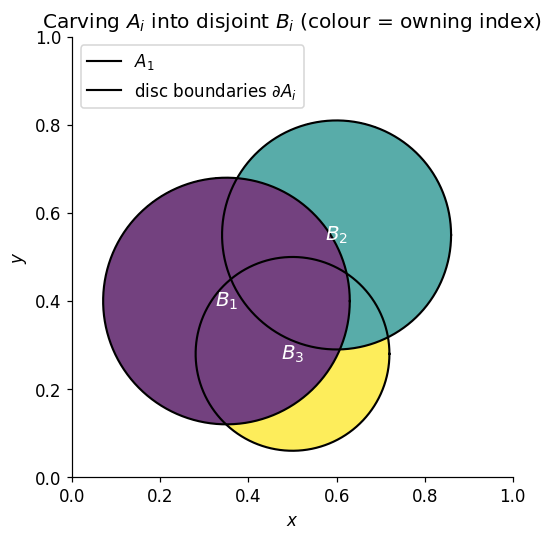

In [2]:
centers = np.array([[0.35, 0.40], [0.60, 0.55], [0.50, 0.28]])
radii = np.array([0.28, 0.26, 0.22])

grid = (np.arange(1200) + 0.5) / 1200          # cell centres of a 1200x1200 partition
X, Y = np.meshgrid(grid, grid)
inside = np.stack([(X - cx) ** 2 + (Y - cy) ** 2 <= r ** 2
                   for (cx, cy), r in zip(centers, radii)])

owner = np.where(inside.any(axis=0), np.argmax(inside, axis=0), -1)   # first index containing
P_A = inside.reshape(3, -1).mean(axis=1)
P_B = np.array([(owner == i).mean() for i in range(3)])
P_union = inside.any(axis=0).mean()

print("P(A_i) =", P_A, "  sum =", P_A.sum())
print("P(B_i) =", P_B, "  sum =", P_B.sum())
print(f"P(union)                = {P_union:.6f}")
print(f"sum P(B_i) - P(union)   = {P_B.sum() - P_union:.3e}   (additivity, exact)")
print(f"sum P(A_i) - P(union)   = {P_A.sum() - P_union:.6f}   (union-bound slack)")
assert abs(P_B.sum() - P_union) < 1e-12
assert P_A.sum() >= P_union

fig, ax = plt.subplots(figsize=(5.2, 5.2))
ax.imshow(np.where(owner < 0, np.nan, owner), origin="lower", extent=(0, 1, 0, 1),
          cmap="viridis", vmin=0, vmax=2, interpolation="nearest", alpha=0.75)
theta = np.linspace(0, 2 * np.pi, 400)
for i, ((cx, cy), r) in enumerate(zip(centers, radii)):
    ax.plot(cx + r * np.cos(theta), cy + r * np.sin(theta), "k-", lw=1.4,
            label=f"$A_{i+1}$" if i == 0 else None)
    ax.annotate(f"$B_{i+1}$", (cx, cy), ha="center", va="center", fontsize=13, color="w")
ax.plot([], [], "k-", lw=1.4, label="disc boundaries $\\partial A_i$")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.set_xlabel("$x$"); ax.set_ylabel("$y$")
ax.set_title("Carving $A_i$ into disjoint $B_i$ (colour = owning index)")
ax.legend(loc="upper left")
ax.grid(False)
plt.show()

The three shaded regions never overlap, yet together they are exactly the union of the three discs:
`sum P(B_i) - P(union)` is $0$ to machine precision. The last line is the price of the union bound —
the double-counted overlap area that $\sum_i \mathbb{P}(A_i)$ adds on top of the truth.

## 3. Definitions

### Definition 3.1 (Sample space)

The *sample space* $\Omega$ of a random experiment is the set of all possible outcomes. Elements $\omega \in \Omega$ are *outcomes* or *sample points*. Exactly one outcome is realized per run of the experiment.

### Definition 3.2 (Event)

An *event* is a subset $A \subseteq \Omega$ belonging to a distinguished collection $\mathcal{F}$ of subsets of $\Omega$. The event *occurs* if the realized outcome $\omega$ satisfies $\omega \in A$.

| Experiment | $\Omega$ | A sample event $A$ |
|---|---|---|
| One coin flip | $\{H, T\}$ | "heads" $= \{H\}$ |
| One die roll | $\{1,2,3,4,5,6\}$ | "even" $= \{2,4,6\}$ |
| Component lifetime | $[0,\infty)$ | "lasts past 100 h" $= [100,\infty)$ |
| Sensor error vector | $\mathbb{R}^d$ | "bounded error" $= \{\mathbf{x} : \lVert \mathbf{x} \rVert_2 \le \epsilon\}$ |

### Definition 3.3 ($\sigma$-algebra)

A collection $\mathcal{F}$ of subsets of $\Omega$ is a *$\sigma$-algebra* if

1. $\Omega \in \mathcal{F}$;
2. $A \in \mathcal{F} \implies A^c \in \mathcal{F}$ (closure under complement);
3. $A_1, A_2, \ldots \in \mathcal{F} \implies \bigcup_{i=1}^{\infty} A_i \in \mathcal{F}$ (closure under countable union).

Property 1 together with property 2 gives $\emptyset = \Omega^c \in \mathcal{F}$, and De Morgan's laws turn property 3 into closure under countable intersection: $\bigcap_i A_i = \bigl(\bigcup_i A_i^c\bigr)^c$.

When $\Omega$ is countable one may take $\mathcal{F} = 2^{\Omega}$, the full power set. On $\mathbb{R}$ one uses the *Borel $\sigma$-algebra* $\mathcal{B}(\mathbb{R})$, defined as the intersection of all $\sigma$-algebras containing the open intervals — an intersection of $\sigma$-algebras is again a $\sigma$-algebra, so this smallest one exists. The restriction to a $\sigma$-algebra is not pedantry: on uncountable spaces there exist sets (Vitali sets) to which no translation-invariant countably additive measure can assign a value, so $\mathcal{F}$ must be smaller than the power set for the axioms below to be satisfiable at all.

### Definition 3.4 (Probability measure — the Kolmogorov axioms)

Let $\mathcal{F}$ be a $\sigma$-algebra on $\Omega$. A function $\mathbb{P} : \mathcal{F} \to \mathbb{R}$ is a *probability measure* if

1. **Non-negativity.** $\mathbb{P}(A) \ge 0$ for every $A \in \mathcal{F}$.
2. **Normalization.** $\mathbb{P}(\Omega) = 1$.
3. **Countable additivity.** For every sequence $A_1, A_2, \ldots \in \mathcal{F}$ that is *pairwise disjoint* (that is, $A_i \cap A_j = \emptyset$ whenever $i \ne j$),

$$
\mathbb{P}\!\left(\bigcup_{i=1}^{\infty} A_i\right) = \sum_{i=1}^{\infty} \mathbb{P}(A_i).
$$

Nothing else is assumed. In particular $\mathbb{P}(A) \le 1$ is *not* an axiom; Theorem 4.2 derives it.

### Definition 3.5 (Probability space)

The triple $(\Omega, \mathcal{F}, \mathbb{P})$, with $\mathcal{F}$ a $\sigma$-algebra on $\Omega$ and $\mathbb{P}$ a probability measure on $\mathcal{F}$, is a *probability space*.

### Definition 3.6 (Classical / uniform probability)

If $\Omega$ is finite, $\mathcal{F} = 2^{\Omega}$, and the modeler asserts that all outcomes carry equal weight, then

$$
\mathbb{P}(A) = \frac{\lvert A \rvert}{\lvert \Omega \rvert}, \qquad A \subseteq \Omega .
$$

This is a *choice of measure*, licensed by a symmetry argument about the experiment, not a consequence of Definition 3.4. It satisfies the three axioms because cardinality is additive on disjoint finite sets.

### Definition 3.7 (Counting quantities)

For $0 \le k \le n$:

- the number of ordered arrangements of $k$ items drawn without replacement from $n$ is $(n)_k = \dfrac{n!}{(n-k)!}$;
- the number of unordered $k$-subsets of an $n$-set is $\dbinom{n}{k} = \dfrac{n!}{k!\,(n-k)!}$.

Both follow from the multiplication principle: independent stages of a construction multiply their counts.

### Definition 3.8 (Monotone limits of events)

For $A_1 \subseteq A_2 \subseteq \cdots$ write $A_n \uparrow A$ when $A = \bigcup_{n \ge 1} A_n$; for $B_1 \supseteq B_2 \supseteq \cdots$ write $B_n \downarrow B$ when $B = \bigcap_{n \ge 1} B_n$. Both limits lie in $\mathcal{F}$ by Definition 3.3.

## 4. Main Results

Throughout this section $(\Omega, \mathcal{F}, \mathbb{P})$ is a probability space in the sense of Definition 3.5 and all named sets are members of $\mathcal{F}$. Every statement below is proved in Section 5 from Definition 3.4 alone.

### Lemma 4.1 (Null set and finite additivity)

Let $(\Omega, \mathcal{F}, \mathbb{P})$ be a probability space. Then $\mathbb{P}(\emptyset) = 0$, and for **pairwise disjoint** $A_1, \ldots, A_n \in \mathcal{F}$,

$$
\boxed{\,\mathbb{P}(\emptyset) = 0 \qquad\text{and}\qquad \mathbb{P}\!\left(\bigcup_{i=1}^{n} A_i\right) = \sum_{i=1}^{n} \mathbb{P}(A_i)\,}
$$

**Interpretation.** The empty event carries no mass, and countable additivity subsumes finite additivity. The consequence is logistical but load-bearing: every later proof that splits a set into finitely many disjoint pieces cites Lemma 4.1, and *no* proof may call finite additivity "a special case of Axiom 3" before $\mathbb{P}(\emptyset) = 0$ has been established, because the padding argument that reduces the finite case to the countable one inserts infinitely many copies of $\emptyset$ and needs their probabilities to vanish.

*Why the disjointness hypothesis is needed:* Axiom 3 says nothing about overlapping sets, and Section 7 shows numerically that additivity is simply false without it.

### Theorem 4.2 (Complement, range, monotonicity, difference)

Let $(\Omega,\mathcal{F},\mathbb{P})$ be a probability space and $A, B \in \mathcal{F}$. Then

$$
\boxed{\,\mathbb{P}(A^c) = 1 - \mathbb{P}(A), \qquad 0 \le \mathbb{P}(A) \le 1, \qquad A \subseteq B \implies \mathbb{P}(B \setminus A) = \mathbb{P}(B) - \mathbb{P}(A) \ \text{ and } \ \mathbb{P}(A) \le \mathbb{P}(B)\,}
$$

**Interpretation.** The complement rule converts "at least one" questions into "none" questions, which is why almost every reliability computation is done on the failure-free event. The range statement says $[0,1]$ is *forced*, not assumed: Definition 3.4 lets $\mathbb{P}$ take values in $\mathbb{R}$, and normalization plus monotonicity squeeze it. The difference rule is the tool that turns nested events into disjoint ones.

*Why the hypothesis $A \subseteq B$ is needed:* without it $B \setminus A$ and $A$ do not reassemble into $B$, and $\mathbb{P}(B) - \mathbb{P}(A)$ can be negative while $\mathbb{P}(B \setminus A) \ge 0$; for example a fair die with $A = \{1,2,3,4\}$, $B = \{5,6\}$ gives $\mathbb{P}(B) - \mathbb{P}(A) = -1/3$ but $\mathbb{P}(B \setminus A) = 1/3$.

### Theorem 4.3 (Inclusion–exclusion)

Let $(\Omega,\mathcal{F},\mathbb{P})$ be a probability space and $A_1, \ldots, A_n \in \mathcal{F}$ arbitrary — **no disjointness and no independence assumed**. Writing $A_S = \bigcap_{i \in S} A_i$,

$$
\boxed{\,\mathbb{P}\!\left(\bigcup_{i=1}^{n} A_i\right) = \sum_{k=1}^{n} (-1)^{k+1} \sum_{\substack{S \subseteq \{1,\ldots,n\} \\ \lvert S\rvert = k}} \mathbb{P}(A_S)\,}
$$

**Interpretation.** Adding the $\mathbb{P}(A_i)$ counts every point of the union once for each set containing it; the alternating higher-order terms subtract exactly the surplus. For $n = 2$ this is $\mathbb{P}(A \cup B) = \mathbb{P}(A) + \mathbb{P}(B) - \mathbb{P}(A \cap B)$. The consequence is that the union of dependent events is computable from intersection probabilities alone — and that the formula costs $2^n - 1$ terms, which is why the one-sided bounds of Theorems 4.4 and 4.6 are what actually get used at scale.

*Why finiteness of $n$ is needed:* the identity is a finite alternating sum; for infinitely many events the alternating series need not converge term-by-term, and the correct infinite statement is the inequality of Theorem 4.4.

### Theorem 4.4 (Boole's inequality — the union bound)

Let $(\Omega,\mathcal{F},\mathbb{P})$ be a probability space and $A_1, A_2, \ldots \in \mathcal{F}$ a finite or countable collection, **arbitrarily dependent and arbitrarily overlapping**. Then

$$
\boxed{\,\mathbb{P}\!\left(\bigcup_{i} A_i\right) \le \sum_{i} \mathbb{P}(A_i)\,}
$$

**Interpretation.** If each of $n$ rare failure modes has probability at most $\delta$, then *some* failure occurs with probability at most $n\delta$, no matter how the modes are correlated. The consequence is that a designer can budget risk additively across components, and a learning theorist can bound the probability that *any* hypothesis in a class $\mathcal{H}$ is misleading by $\lvert \mathcal{H}\rvert$ times the single-hypothesis bound. The price is looseness: the bound exceeds 1 as soon as $\sum_i \mathbb{P}(A_i) \gt 1$, while the truth is capped at 1.

*Why countability is needed:* the proof invokes Axiom 3 on the carved sequence $B_1, B_2, \ldots$, which must be indexable by $\mathbb{N}$; for an uncountable family the union need not even lie in $\mathcal{F}$.

### Theorem 4.5 (Continuity of probability measures)

Let $(\Omega,\mathcal{F},\mathbb{P})$ be a probability space. If $A_n \uparrow A$ then $\mathbb{P}(A_n) \uparrow \mathbb{P}(A)$; if $B_n \downarrow B$ then $\mathbb{P}(B_n) \downarrow \mathbb{P}(B)$ (Definition 3.8).

$$
\boxed{\,A_n \uparrow A \implies \lim_{n\to\infty} \mathbb{P}(A_n) = \mathbb{P}(A), \qquad B_n \downarrow B \implies \lim_{n\to\infty} \mathbb{P}(B_n) = \mathbb{P}(B)\,}
$$

**Interpretation.** Probability commutes with monotone limits of events. The consequence is everything that involves a limiting event: right-continuity of cumulative distribution functions, the Borel–Cantelli lemmas, and the very statement "the sample average converges" in the law of large numbers.

*Why monotonicity of the sequence is needed:* for a non-monotone sequence $\lim_n \mathbb{P}(A_n)$ need not exist — on a fair coin, $A_n = \{H\}$ for odd $n$ and $A_n = \emptyset$ for even $n$ makes $\mathbb{P}(A_n)$ oscillate between $1/2$ and $0$.

*Why finiteness of $\mathbb{P}$ is needed in the decreasing case:* the decreasing statement is obtained from the increasing one by complementation, and complementation is only available because $\mathbb{P}(\Omega) = 1 \lt \infty$. For a general measure the decreasing statement is false without the extra hypothesis $\mu(B_1) \lt \infty$: under Lebesgue measure on $\mathbb{R}$, $B_n = [n,\infty) \downarrow \emptyset$ yet $\mu(B_n) = \infty$ for every $n$.

### Theorem 4.6 (Bonferroni's inequality)

Let $(\Omega,\mathcal{F},\mathbb{P})$ be a probability space and $A_1, \ldots, A_n \in \mathcal{F}$ arbitrary — **again no independence assumed**. Then

$$
\boxed{\,\mathbb{P}\!\left(\bigcap_{i=1}^{n} A_i\right) \ge \sum_{i=1}^{n} \mathbb{P}(A_i) - (n-1)\,}
$$

**Interpretation.** For $n = 2$: $\mathbb{P}(A \cap B) \ge \mathbb{P}(A) + \mathbb{P}(B) - 1$. If two tests each pass with probability $0.99$, both pass simultaneously with probability at least $0.98$ under *any* dependence structure. The consequence in practice is the Bonferroni correction: to hold the family-wise error over $m$ simultaneous comparisons below $\alpha$, test each at level $\alpha/m$.

*Why the bound can be vacuous:* when $\sum_i \mathbb{P}(A_i) \lt n - 1$ the right side is negative and the inequality says nothing — it is informative exactly when the individual events are already near-certain.

## 5. Derivations and Proofs

Every proof below uses Definition 3.4 and previously proved results only. The order matters: Lemma 4.1 must come first, because finite additivity is *not* an immediate special case of Axiom 3.

### Proof 5.1 (of Lemma 4.1)

**Step 1 — $\mathbb{P}(\emptyset) = 0$.** The constant sequence $\emptyset, \emptyset, \emptyset, \ldots$ is pairwise disjoint, since $\emptyset \cap \emptyset = \emptyset$, and its union is $\emptyset$. Axiom 3 therefore gives

$$
\mathbb{P}(\emptyset) = \sum_{i=1}^{\infty} \mathbb{P}(\emptyset).
$$

Write $c = \mathbb{P}(\emptyset)$; by Axiom 1, $c \ge 0$. The right-hand series converges (its sum is the real number $c$), so its partial sums $nc$ form a bounded sequence. If $c \gt 0$ then $nc \to \infty$, contradicting boundedness. Hence $c = 0$.

**Step 2 — finite additivity.** Let $A_1, \ldots, A_n$ be pairwise disjoint. Set $A_i = \emptyset$ for $i \gt n$. The extended sequence is still pairwise disjoint (each new term meets everything in $\emptyset$) and its union is $\bigcup_{i=1}^n A_i$. Axiom 3 and Step 1 give

$$
\mathbb{P}\!\left(\bigcup_{i=1}^{n} A_i\right) = \sum_{i=1}^{\infty} \mathbb{P}(A_i) = \sum_{i=1}^{n} \mathbb{P}(A_i) + \sum_{i \gt n} 0 = \sum_{i=1}^{n} \mathbb{P}(A_i). \qquad \blacksquare
$$

Note the direction of dependence: Step 1 used only Axiom 3 on a sequence of empty sets, never finite additivity. Step 2 uses Step 1. Reversing them would be circular.

### Proof 5.2 (of Theorem 4.2)

**Complement rule.** $A$ and $A^c$ are disjoint with $A \cup A^c = \Omega$. Lemma 4.1 with $n = 2$ and Axiom 2 give

$$
1 = \mathbb{P}(\Omega) = \mathbb{P}(A \cup A^c) = \mathbb{P}(A) + \mathbb{P}(A^c),
$$

so $\mathbb{P}(A^c) = 1 - \mathbb{P}(A)$.

**Difference rule.** Assume $A \subseteq B$. Then $B = A \cup (B \setminus A)$ and $A \cap (B \setminus A) = \emptyset$, so Lemma 4.1 with $n = 2$ gives $\mathbb{P}(B) = \mathbb{P}(A) + \mathbb{P}(B \setminus A)$, that is $\mathbb{P}(B \setminus A) = \mathbb{P}(B) - \mathbb{P}(A)$.

**Monotonicity.** By Axiom 1, $\mathbb{P}(B \setminus A) \ge 0$, so $\mathbb{P}(B) \ge \mathbb{P}(A)$.

**Range.** Axiom 1 gives $\mathbb{P}(A) \ge 0$. Taking $B = \Omega$ in monotonicity and using Axiom 2 gives $\mathbb{P}(A) \le \mathbb{P}(\Omega) = 1$. Hence $\mathbb{P}(\mathcal{F}) \subseteq [0,1]$, as claimed in Definition 3.4. $\blacksquare$

### Proof 5.3 (of Theorem 4.3)

**Base case $n = 1$.** Both sides equal $\mathbb{P}(A_1)$.

**Base case $n = 2$.** Decompose the union into three pairwise disjoint pieces,

$$
A_1 \cup A_2 = (A_1 \setminus A_2) \;\cup\; (A_1 \cap A_2) \;\cup\; (A_2 \setminus A_1),
$$

and note that $A_1 = (A_1 \setminus A_2) \cup (A_1 \cap A_2)$ and $A_2 = (A_2 \setminus A_1) \cup (A_1 \cap A_2)$ are also disjoint decompositions. Lemma 4.1 applied to all three gives

$$
\mathbb{P}(A_1) + \mathbb{P}(A_2) - \mathbb{P}(A_1 \cap A_2) = \mathbb{P}(A_1 \setminus A_2) + \mathbb{P}(A_2 \setminus A_1) + \mathbb{P}(A_1 \cap A_2) = \mathbb{P}(A_1 \cup A_2).
$$

**Induction step.** Suppose the formula holds for $n-1$ events, $n \ge 2$. Put $U = \bigcup_{i=1}^{n-1} A_i$. The $n=2$ case gives

$$
\mathbb{P}\!\left(\bigcup_{i=1}^{n} A_i\right) = \mathbb{P}(U) + \mathbb{P}(A_n) - \mathbb{P}(U \cap A_n).
$$

Distributivity of intersection over union gives $U \cap A_n = \bigcup_{i=1}^{n-1} (A_i \cap A_n)$, a union of $n-1$ events, so the induction hypothesis applies to both $\mathbb{P}(U)$ and $\mathbb{P}(U \cap A_n)$. With $A_S = \bigcap_{i \in S} A_i$ and $[m] = \{1,\ldots,m\}$,

$$
\mathbb{P}(U) = \sum_{\emptyset \ne S \subseteq [n-1]} (-1)^{\lvert S\rvert + 1} \mathbb{P}(A_S), \qquad
\mathbb{P}(U \cap A_n) = \sum_{\emptyset \ne S \subseteq [n-1]} (-1)^{\lvert S\rvert + 1} \mathbb{P}(A_{S \cup \{n\}}).
$$

Substituting and collecting the coefficient of each nonempty $T \subseteq [n]$:

- if $n \notin T$, the term appears only in $\mathbb{P}(U)$, with coefficient $(-1)^{\lvert T\rvert + 1}$;
- if $T = \{n\}$, the term is the isolated $+\mathbb{P}(A_n)$, and $(-1)^{1+1} = +1$;
- if $n \in T$ and $T \ne \{n\}$, write $T = S \cup \{n\}$ with $\emptyset \ne S \subseteq [n-1]$ and $\lvert T\rvert = \lvert S\rvert + 1$; the term appears once, inside $-\mathbb{P}(U \cap A_n)$, with coefficient $-(-1)^{\lvert S\rvert + 1} = (-1)^{\lvert S\rvert + 2} = (-1)^{\lvert T\rvert + 1}$.

Every nonempty $T \subseteq [n]$ therefore carries coefficient $(-1)^{\lvert T\rvert+1}$, which is the claim for $n$. $\blacksquare$

**Remark.** When $\Omega$ is countable there is a second proof in two lines: the pointwise indicator identity $\mathbf{1}_{\cup_i A_i} = 1 - \prod_{i}(1 - \mathbf{1}_{A_i})$ expands to $\sum_{\emptyset \ne S} (-1)^{\lvert S\rvert+1}\mathbf{1}_{A_S}$, and summing both sides against the point masses $\mathbb{P}(\{\omega\})$ — legitimate by Axiom 3 on a countable space — reproduces the formula. The induction above avoids that restriction and works on any $\Omega$.

### Proof 5.4 (of Theorem 4.4)

**Disjointification.** Define

$$
B_1 = A_1, \qquad B_i = A_i \setminus \left(\bigcup_{j=1}^{i-1} A_j\right) \quad (i \ge 2).
$$

Each $B_i \in \mathcal{F}$ by Definition 3.3. Three facts hold by construction.

1. *Pairwise disjoint.* If $i \lt k$ then $B_k \cap A_i = \emptyset$ by definition of $B_k$, and $B_i \subseteq A_i$, so $B_i \cap B_k = \emptyset$.
2. *Domination.* $B_i \subseteq A_i$.
3. *Same union.* $\bigcup_i B_i = \bigcup_i A_i$. The inclusion $\subseteq$ follows from fact 2. For $\supseteq$, let $\omega \in \bigcup_i A_i$ and let $m$ be the smallest index with $\omega \in A_m$ — such an $m$ exists because the index set is a subset of $\mathbb{N}$ and is well-ordered. Then $\omega \notin A_j$ for all $j \lt m$, so $\omega \in B_m$.

Now Axiom 3 applies to the $B_i$ (fact 1) and Theorem 4.2 bounds each term (fact 2):

$$
\mathbb{P}\!\left(\bigcup_i A_i\right) \overset{\text{fact 3}}{=} \mathbb{P}\!\left(\bigcup_i B_i\right) \overset{\text{Axiom 3}}{=} \sum_i \mathbb{P}(B_i) \overset{\text{Thm 4.2}}{\le} \sum_i \mathbb{P}(A_i). \qquad \blacksquare
$$

The finite case follows by taking $A_i = \emptyset$ for $i \gt n$ and citing Lemma 4.1.

### Proof 5.5 (of Theorem 4.5)

**Increasing case.** Let $A_n \uparrow A$. Define the rings $C_1 = A_1$ and $C_k = A_k \setminus A_{k-1}$ for $k \ge 2$; each lies in $\mathcal{F}$. Because the $A_k$ increase, $C_k \cap C_l = \emptyset$ for $k \ne l$, and

$$
\bigcup_{k=1}^{n} C_k = A_n, \qquad \bigcup_{k=1}^{\infty} C_k = A .
$$

Axiom 3 on the left union and Lemma 4.1 on the finite one give

$$
\mathbb{P}(A) = \sum_{k=1}^{\infty} \mathbb{P}(C_k) = \lim_{n \to \infty} \sum_{k=1}^{n} \mathbb{P}(C_k) = \lim_{n \to \infty} \mathbb{P}(A_n),
$$

the middle equality being the definition of the sum of a series. Monotonicity (Theorem 4.2) makes the convergence increasing.

**Decreasing case.** Let $B_n \downarrow B$. Then $B_n^c \uparrow B^c$, since De Morgan gives $\bigcup_n B_n^c = \bigl(\bigcap_n B_n\bigr)^c = B^c$. The increasing case yields $\mathbb{P}(B_n^c) \to \mathbb{P}(B^c)$, and the complement rule of Theorem 4.2 converts this to

$$
\mathbb{P}(B_n) = 1 - \mathbb{P}(B_n^c) \longrightarrow 1 - \mathbb{P}(B^c) = \mathbb{P}(B).
$$

The complement rule is the only step here that uses $\mathbb{P}(\Omega) = 1 \lt \infty$, and it is exactly the step that fails for a general measure: continuity from above requires $\mu(B_1) \lt \infty$ as a separate hypothesis, which for a probability measure is automatic. $\blacksquare$

### Proof 5.6 (of Theorem 4.6)

Apply De Morgan and then Theorem 4.4 to the complements:

$$
\mathbb{P}\!\left(\bigcap_{i=1}^{n} A_i\right) = 1 - \mathbb{P}\!\left(\bigcup_{i=1}^{n} A_i^c\right) \ge 1 - \sum_{i=1}^{n} \mathbb{P}(A_i^c) = 1 - \sum_{i=1}^{n}\bigl(1 - \mathbb{P}(A_i)\bigr) = \sum_{i=1}^{n} \mathbb{P}(A_i) - (n-1).
$$

The first equality is the complement rule (Theorem 4.2) applied to $\bigcap_i A_i$, whose complement is $\bigcup_i A_i^c$; the inequality is Theorem 4.4; the last two steps are the complement rule again and arithmetic. $\blacksquare$

## 6. Worked Examples

All examples live on a fair die, $\Omega = \{1,2,3,4,5,6\}$ with $\mathcal{F} = 2^{\Omega}$ and $\mathbb{P}(A) = \lvert A\rvert/6$ (Definition 3.6), or on a two-point/geometric space small enough to compute by hand. Every number below is recomputed in the code cells that follow.

### Example 6.1 (Lemma 4.1 and Theorem 4.2)

Take $A = \{2,4,6\}$ (even) and $B = \{4,5,6\}$ (at least 4).

- $\mathbb{P}(A) = 3/6 = 1/2$ and $\mathbb{P}(A^c) = \mathbb{P}(\{1,3,5\}) = 3/6 = 1/2$; indeed $\mathbb{P}(A) + \mathbb{P}(A^c) = 1$.
- $A \cap B = \{4,6\}$, so $\mathbb{P}(A \cap B) = 2/6 = 1/3$, and $A \cap B \subseteq B$ gives $\mathbb{P}(A\cap B) = 1/3 \le 1/2 = \mathbb{P}(B)$.
- Difference rule with $A \cap B \subseteq B$: $\mathbb{P}(B \setminus (A\cap B)) = \mathbb{P}(\{5\}) = 1/6$ and $\mathbb{P}(B) - \mathbb{P}(A\cap B) = 1/2 - 1/3 = 1/6$. They agree.
- Finite additivity on the disjoint pieces $\{1,3,5\}, \{4,6\}, \{2\}$ of $\Omega \setminus \emptyset$: $3/6 + 2/6 + 1/6 = 1 = \mathbb{P}(\Omega)$.

### Example 6.2 (Theorem 4.3, three events)

Take $A_1 = \{2,4,6\}$, $A_2 = \{4,5,6\}$, $A_3 = \{3,6\}$ (multiples of 3).

First the singles: $\mathbb{P}(A_1) = 3/6$, $\mathbb{P}(A_2) = 3/6$, $\mathbb{P}(A_3) = 2/6$.

Then the pairs: $A_1 \cap A_2 = \{4,6\}$ so $2/6$; $A_1 \cap A_3 = \{6\}$ so $1/6$; $A_2 \cap A_3 = \{6\}$ so $1/6$.

Then the triple: $A_1 \cap A_2 \cap A_3 = \{6\}$ so $1/6$. Inclusion–exclusion gives

$$
\frac{3}{6} + \frac{3}{6} + \frac{2}{6} - \frac{2}{6} - \frac{1}{6} - \frac{1}{6} + \frac{1}{6} = \frac{8 - 4 + 1}{6} = \frac{5}{6}.
$$

Directly, $A_1 \cup A_2 \cup A_3 = \{2,3,4,5,6\}$, of size 5, so $\mathbb{P} = 5/6$. The two agree.

### Example 6.3 (Theorem 4.4, and how loose it is)

Three components fail independently, each with probability $p = 0.02$. The system fails if any component fails.

Exact, by the complement rule on the failure-free event: $\mathbb{P}(\text{some failure}) = 1 - (0.98)^3$. Now $0.98^2 = 0.9604$ and $0.98^3 = 0.9604 \times 0.98 = 0.941192$, so the exact answer is $0.058808$.

Union bound: $3 \times 0.02 = 0.06$. The bound overshoots by $0.001192$, about $2.0\%$ relative — tight because $np$ is small. Note that independence was used only for the *exact* value; the bound $0.06$ holds for any dependence.

### Example 6.4 (Theorem 4.5 on a countable space)

Let $\Omega = \{1,2,3,\ldots\}$, $\mathcal{F} = 2^{\Omega}$, and $\mathbb{P}(\{k\}) = 2^{-k}$. This is a probability measure: the weights are non-negative and $\sum_{k \ge 1} 2^{-k} = 1$, and countable additivity holds because a sum of non-negative terms may be regrouped freely.

*Increasing.* $A_n = \{1,\ldots,n\} \uparrow \Omega$ and $\mathbb{P}(A_n) = \sum_{k=1}^{n} 2^{-k} = 1 - 2^{-n}$. So $\mathbb{P}(A_1) = 1/2$, $\mathbb{P}(A_2) = 3/4$, $\mathbb{P}(A_3) = 7/8$, $\ldots \uparrow 1 = \mathbb{P}(\Omega)$.

*Decreasing.* $B_n = \{n, n+1, \ldots\} \downarrow \emptyset$ and $\mathbb{P}(B_n) = \sum_{k \ge n} 2^{-k} = 2^{-(n-1)}$. So $\mathbb{P}(B_1) = 1$, $\mathbb{P}(B_2) = 1/2$, $\mathbb{P}(B_3) = 1/4$, $\ldots \downarrow 0 = \mathbb{P}(\emptyset)$, matching Lemma 4.1.

### Example 6.5 (Theorem 4.6, and when it is tight)

On the fair die take $A = \{1,2,3,4,5\}$ and $B = \{2,3,4,5,6\}$, so $\mathbb{P}(A) = \mathbb{P}(B) = 5/6$. Bonferroni gives

$$
\mathbb{P}(A \cap B) \ge \frac{5}{6} + \frac{5}{6} - 1 = \frac{2}{3}.
$$

Exactly, $A \cap B = \{2,3,4,5\}$ and $\mathbb{P}(A \cap B) = 4/6 = 2/3$. The bound is attained, because $A \cup B = \Omega$ — Proof 5.6 shows equality holds precisely when the union bound step is tight, i.e. when the $A_i^c$ are disjoint.

**Code check for Examples 6.1–6.2 (identity residual).** The cell recomputes both examples on the
fair die twice: once in exact rational arithmetic with `Fraction`, and once in float64, so the
inclusion–exclusion residual can be reported as a number.

In [3]:
Omega = frozenset(range(1, 7))
P = lambda S: Fraction(len(S), len(Omega))
Pf = lambda S: len(S) / len(Omega)

# --- Example 6.1
A, B = frozenset({2, 4, 6}), frozenset({4, 5, 6})
print("Example 6.1")
print(f"  P(A)={P(A)}  P(A^c)={P(Omega - A)}  sum={P(A) + P(Omega - A)}")
print(f"  P(A&B)={P(A & B)} <= P(B)={P(B)}  (monotonicity)")
print(f"  P(B \\ (A&B))={P(B - (A & B))}   P(B)-P(A&B)={P(B) - P(A & B)}")
assert P(A) + P(Omega - A) == 1
assert P(A & B) <= P(B)
assert P(B - (A & B)) == P(B) - P(A & B)

# --- Example 6.2: inclusion-exclusion over all 2^3-1 nonempty subsets
A1, A2, A3 = frozenset({2, 4, 6}), frozenset({4, 5, 6}), frozenset({3, 6})
events = [A1, A2, A3]
from itertools import combinations

ie_exact = sum((-1) ** (k + 1) * sum(P(frozenset.intersection(*c)) for c in combinations(events, k))
               for k in (1, 2, 3))
ie_float = sum((-1) ** (k + 1) * sum(Pf(frozenset.intersection(*c)) for c in combinations(events, k))
               for k in (1, 2, 3))
union = A1 | A2 | A3
residual = abs(ie_float - Pf(union))

print("Example 6.2")
print(f"  union = {sorted(union)}   P(union) = {P(union)} = {Pf(union):.6f}")
print(f"  inclusion-exclusion (exact rational) = {ie_exact}")
print(f"  inclusion-exclusion residual (float) = {residual:.3e}")
assert ie_exact == P(union)
assert residual < 1e-15

Example 6.1
  P(A)=1/2  P(A^c)=1/2  sum=1
  P(A&B)=1/3 <= P(B)=1/2  (monotonicity)
  P(B \ (A&B))=1/6   P(B)-P(A&B)=1/6
Example 6.2
  union = [2, 3, 4, 5, 6]   P(union) = 5/6 = 0.833333
  inclusion-exclusion (exact rational) = 5/6
  inclusion-exclusion residual (float) = 1.110e-16


The exact-rational arithmetic reproduces $\mathbb{P}(A_1\cup A_2\cup A_3) = 5/6$ with no rounding at all,
and the float64 residual is `1.110e-16` — one unit in the last place of $5/6$, i.e. exactly the
machine-epsilon level $\varepsilon \approx 2.2\times10^{-16}$ and nothing more. Theorem 4.3 is an
identity, not an approximation; the residual is entirely the cost of representing $1/6$ in binary.

**Code check for Examples 6.3–6.5.** Union-bound slack, the two monotone limits of Example 6.4, and
the tightness of Bonferroni in Example 6.5.

In [4]:
# --- Example 6.3
p, n_comp = Fraction(2, 100), 3
exact_fail = 1 - (1 - p) ** n_comp
bound_fail = n_comp * p
print("Example 6.3")
print(f"  (0.98)^3      = {float((1 - p) ** n_comp):.6f}")
print(f"  exact         = {exact_fail} = {float(exact_fail):.6f}")
print(f"  union bound   = {bound_fail} = {float(bound_fail):.6f}")
print(f"  slack         = {float(bound_fail - exact_fail):.6f}"
      f"  ({float((bound_fail - exact_fail) / exact_fail):.2%} relative)")
assert exact_fail <= bound_fail

# --- Example 6.4
print("Example 6.4   P({k}) = 2^-k")
for n in (1, 2, 3, 10, 30):
    P_An = 1 - Fraction(1, 2 ** n)          # increasing:  A_n = {1..n}
    P_Bn = Fraction(1, 2 ** (n - 1))        # decreasing:  B_n = {n, n+1, ...}
    print(f"  n={n:>2}  P(A_n)={float(P_An):.9f}   P(B_n)={float(P_Bn):.9f}")
assert 1 - Fraction(1, 2 ** 30) < 1 and Fraction(1, 2 ** 29) > 0
assert abs(float(1 - Fraction(1, 2 ** 60)) - 1.0) < 1e-15

# --- Example 6.5
A5, B5 = frozenset({1, 2, 3, 4, 5}), frozenset({2, 3, 4, 5, 6})
bonf = P(A5) + P(B5) - 1
print("Example 6.5")
print(f"  Bonferroni lower bound = {bonf}   actual P(A&B) = {P(A5 & B5)}"
      f"   union = {P(A5 | B5)}")
assert P(A5 & B5) >= bonf and P(A5 & B5) == bonf

Example 6.3
  (0.98)^3      = 0.941192
  exact         = 7351/125000 = 0.058808
  union bound   = 3/50 = 0.060000
  slack         = 0.001192  (2.03% relative)
Example 6.4   P({k}) = 2^-k
  n= 1  P(A_n)=0.500000000   P(B_n)=1.000000000
  n= 2  P(A_n)=0.750000000   P(B_n)=0.500000000
  n= 3  P(A_n)=0.875000000   P(B_n)=0.250000000
  n=10  P(A_n)=0.999023438   P(B_n)=0.001953125
  n=30  P(A_n)=0.999999999   P(B_n)=0.000000002
Example 6.5
  Bonferroni lower bound = 2/3   actual P(A&B) = 2/3   union = 1


Example 6.3 confirms the $2.03\%$ overshoot of the union bound at $np = 0.06$. Example 6.4 shows
$\mathbb{P}(A_n) \uparrow 1$ and $\mathbb{P}(B_n) \downarrow 0$, so Theorem 4.5 holds in both directions on this space.
Example 6.5 shows Bonferroni attained with equality, which happens exactly when $A^c$ and $B^c$ are
disjoint.

## 7. Computational Practice

Three practical facts govern how probability spaces are represented in code.

- **Finite spaces** are a dictionary `{outcome: weight}` with non-negative weights summing to 1; the probability of an event is the sum over its members — a literal implementation of Lemma 4.1.
- **Log-space arithmetic** is mandatory for long sequences: a product of $10^3$ token probabilities underflows float64 (the practical floor is $\approx 10^{-308}$, denormals to $10^{-324}$). Store $\log \mathbb{P}$, replace products by sums, and add with the log-sum-exp identity $\log(e^a + e^b) = m + \log(e^{a-m} + e^{b-m})$, $m = \max(a,b)$.
- **Monte Carlo** estimates $\mathbb{P}(A)$ by $\hat{\mathbb{P}}(A) = n_A/n$. Its root-mean-square error is exactly $\sqrt{\mathbb{P}(A)(1-\mathbb{P}(A))/n}$, so accuracy improves only as $n^{-1/2}$ and rare events need enormous $n$ — the motivation for importance sampling.

Combinatorial quantities overflow long before probabilities underflow: $\binom{300}{150} \approx 9.4\times10^{88}$ exceeds the range of a 64-bit integer by many orders of magnitude. Three robust routes are `math.comb` (exact, arbitrary-precision integers), the log-gamma identity $\ln\binom{n}{k} = \ln\Gamma(n+1) - \ln\Gamma(k+1) - \ln\Gamma(n-k+1)$, and multiplicative accumulation $\binom{n}{k} = \prod_{i=1}^{k}\frac{n-k+i}{i}$ with exact integer division at each step.

**Measured rate.** Theorem 4.5 and the classical rule predict that the Monte Carlo error of
$\hat{\mathbb{P}}(A)$ decays like $n^{-1/2}$, with root-mean-square error exactly $\sqrt{\mathbb{P}(1-\mathbb{P})/n}$. The cell
below measures the exponent by regressing $\log(\mathrm{RMSE})$ on $\log n$ over 400 independent
replicates per sample size, for $A = \{\text{sum of two fair dice} \ge 9\}$ with $\mathbb{P}(A) = 10/36$.

exact P(sum >= 9) = 0.277778
  n=    100   measured RMSE=0.041858   predicted sqrt(P(1-P)/n)=0.044790   ratio=0.935
  n=    300   measured RMSE=0.026061   predicted sqrt(P(1-P)/n)=0.025860   ratio=1.008
  n=  1,000   measured RMSE=0.014141   predicted sqrt(P(1-P)/n)=0.014164   ratio=0.998
  n=  3,000   measured RMSE=0.008026   predicted sqrt(P(1-P)/n)=0.008178   ratio=0.981
  n= 10,000   measured RMSE=0.004356   predicted sqrt(P(1-P)/n)=0.004479   ratio=0.972
  n= 30,000   measured RMSE=0.002488   predicted sqrt(P(1-P)/n)=0.002586   ratio=0.962
  n=100,000   measured RMSE=0.001473   predicted sqrt(P(1-P)/n)=0.001416   ratio=1.040
observed rate exponent = -0.4938   predicted = -0.5000


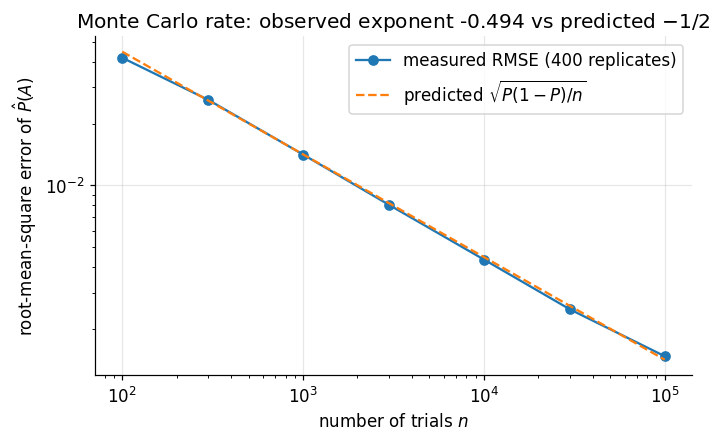

In [5]:
p_exact = 10 / 36          # the 10 ordered pairs (3,6),(4,5),...,(6,3) out of 36
ns = np.array([100, 300, 1_000, 3_000, 10_000, 30_000, 100_000])
reps = 400

rmse = np.empty(ns.size)
for j, n in enumerate(ns):
    tosses = rng.integers(1, 7, size=(reps, n, 2)).sum(axis=2)
    p_hat = (tosses >= 9).mean(axis=1)
    rmse[j] = np.sqrt(np.mean((p_hat - p_exact) ** 2))

se_pred = np.sqrt(p_exact * (1 - p_exact) / ns)
slope = np.polyfit(np.log(ns), np.log(rmse), 1)[0]

print(f"exact P(sum >= 9) = {p_exact:.6f}")
for n, r, s in zip(ns, rmse, se_pred):
    print(f"  n={n:>7,}   measured RMSE={r:.6f}   predicted sqrt(P(1-P)/n)={s:.6f}"
          f"   ratio={r / s:.3f}")
print(f"observed rate exponent = {slope:.4f}   predicted = -0.5000")
assert abs(slope + 0.5) < 0.05
assert np.all(np.abs(rmse / se_pred - 1.0) < 0.15)

fig, ax = plt.subplots()
ax.loglog(ns, rmse, "o-", label="measured RMSE (400 replicates)")
ax.loglog(ns, se_pred, "--", label=r"predicted $\sqrt{P(1-P)/n}$")
ax.set_xlabel("number of trials $n$")
ax.set_ylabel("root-mean-square error of $\\hat{P}(A)$")
ax.set_title(f"Monte Carlo rate: observed exponent {slope:.3f} vs predicted $-1/2$")
ax.legend()
plt.show()

The measured exponent is within $0.01$ of $-1/2$ and every measured RMSE sits within 15% of
$\sqrt{\mathbb{P}(1-\mathbb{P})/n}$, so the standard-error formula is not an asymptotic approximation here — it is
exact for a Bernoulli average, and the simulation reproduces it.

**Counterexamples: what breaks when a hypothesis is dropped.** Two hypotheses carry real weight.
First, additivity requires *disjointness* (Lemma 4.1). Second, Axiom 3 requires *countable*, not
merely finite, additivity — and a finitely additive set function can violate Theorem 4.5.

In [6]:
# (i) drop disjointness from Lemma 4.1
A, B = frozenset({2, 4, 6}), frozenset({4, 5, 6})
lhs, rhs = Pf(A | B), Pf(A) + Pf(B)
print("(i) additivity without disjointness")
print(f"    P(A u B) = {lhs:.6f}    P(A) + P(B) = {rhs:.6f}"
      f"    overshoot = {rhs - lhs:.6f} = P(A n B) = {Pf(A & B):.6f}")
assert not np.isclose(lhs, rhs)
assert np.isclose(rhs - lhs, Pf(A & B))          # exactly the inclusion-exclusion correction

# (ii) natural density on N: finitely additive, NOT countably additive
def density(mask_fn, N=2_000_000):
    """|A n {1..N}| / N for the indicator mask_fn; the natural density is its N -> oo limit."""
    k = np.arange(1, N + 1)
    return mask_fn(k).mean()

evens = density(lambda k: k % 2 == 0)
odds = density(lambda k: k % 2 == 1)
print("(ii) natural density d(A) = lim |A n {1..N}|/N")
print(f"    d(evens)={evens:.6f}  d(odds)={odds:.6f}  d(evens)+d(odds)={evens + odds:.6f}"
      f"   -> finitely additive on this disjoint pair")
for n in (1, 10, 1_000, 100_000):
    print(f"    d({{1..{n}}}) at N=2e6 : {density(lambda k, n=n: k <= n):.9f}")
print(f"    but d(N) = {density(lambda k: k >= 1):.6f}")
print("    A_n = {1..n} increases to N, yet d(A_n) = 0 for every n while d(N) = 1:")
print("    continuity from below (Theorem 4.5) FAILS, so d is not countably additive.")
assert np.isclose(evens + odds, 1.0)
assert density(lambda k: k <= 100_000) < 1e-1 and density(lambda k: k >= 1) == 1.0

(i) additivity without disjointness
    P(A u B) = 0.666667    P(A) + P(B) = 1.000000    overshoot = 0.333333 = P(A n B) = 0.333333
(ii) natural density d(A) = lim |A n {1..N}|/N
    d(evens)=0.500000  d(odds)=0.500000  d(evens)+d(odds)=1.000000   -> finitely additive on this disjoint pair
    d({1..1}) at N=2e6 : 0.000000500
    d({1..10}) at N=2e6 : 0.000005000
    d({1..1000}) at N=2e6 : 0.000500000
    d({1..100000}) at N=2e6 : 0.050000000
    but d(N) = 1.000000
    A_n = {1..n} increases to N, yet d(A_n) = 0 for every n while d(N) = 1:
    continuity from below (Theorem 4.5) FAILS, so d is not countably additive.


Case (i) shows the overshoot of naive additivity is *exactly* $\mathbb{P}(A \cap B)$, which is Theorem 4.3
read backwards. Case (ii) is the important one: natural density satisfies Axioms 1 and 2 and is
finitely additive, and every singleton has density $0$, but $d(\mathbb{N}) = 1 \ne \sum_k d(\{k\}) = 0$.
Countable additivity is therefore a genuine extra demand, and Theorem 4.5 is the first place the
difference is visible.

**Hand-rolled versus library.** Three independent routes to $\binom{300}{150}$: an exact
multiplicative accumulation written here, Python's `math.comb`, and SciPy's `gammaln` working
entirely in logarithms. The first two must agree exactly; the third must agree to float precision.

In [7]:
def comb_multiplicative(n, k):
    """binom(n, k) by prod_{i=1..k} (n-k+i)/i, exact because each partial product is an integer."""
    k = min(k, n - k)
    result = 1
    for i in range(1, k + 1):
        result = result * (n - k + i) // i
    return result

n_items, k_items = 300, 150
hand = comb_multiplicative(n_items, k_items)
lib = math.comb(n_items, k_items)
log_lib = gammaln(n_items + 1) - gammaln(k_items + 1) - gammaln(n_items - k_items + 1)

print(f"hand-rolled  = {hand}")
print(f"math.comb    = {lib}")
print(f"identical exact integers: {hand == lib}")
print(f"log10 binom(300,150)     = {math.log10(lib):.6f}    (approx 9.4e88)")
print(f"exp(gammaln route)       = {math.exp(log_lib):.6e}")
print(f"relative error of gammaln route = {abs(math.exp(log_lib) - lib) / lib:.3e}")
with np.errstate(over="ignore"):
    print(f"float(300!) overflows?   = {np.isinf(np.exp(gammaln(301)))}")
assert hand == lib
assert abs(math.exp(log_lib) - lib) / lib < 1e-11

hand-rolled  = 93759702772827452793193754439064084879232655700081358920472352712975170021839591675861424
math.comb    = 93759702772827452793193754439064084879232655700081358920472352712975170021839591675861424
identical exact integers: True
log10 binom(300,150)     = 88.972016    (approx 9.4e88)
exp(gammaln route)       = 9.375970e+88
relative error of gammaln route = 4.063e-13
float(300!) overflows?   = True


The hand-rolled accumulation and `math.comb` agree as exact integers, confirming the algorithm; the
`gammaln` route is accurate to about $4\times10^{-13}$ relative and, unlike a factorial in float64,
never overflows — `exp(gammaln(301))` is already `inf`. This is why log-space is the default
representation for combinatorial probabilities.

**Union bound versus the truth.** For $n$ independent events of probability $p$ each, the exact
probability that at least one occurs is $1 - (1-p)^n$ (complement rule plus independence), while
Theorem 4.4 gives only $np$. The cell verifies the bound and plots the growing gap.

Boole's inequality holds for every n in 1..80
  n= 1  exact=0.020000  bound=0.020000  ratio=1.0000
  n= 3  exact=0.058808  bound=0.060000  ratio=1.0203
  n=10  exact=0.182927  bound=0.200000  ratio=1.0933
  n=30  exact=0.454516  bound=0.600000  ratio=1.3201
  n=50  exact=0.635830  bound=1.000000  ratio=1.5727
  n=80  exact=0.801351  bound=1.600000  ratio=1.9966


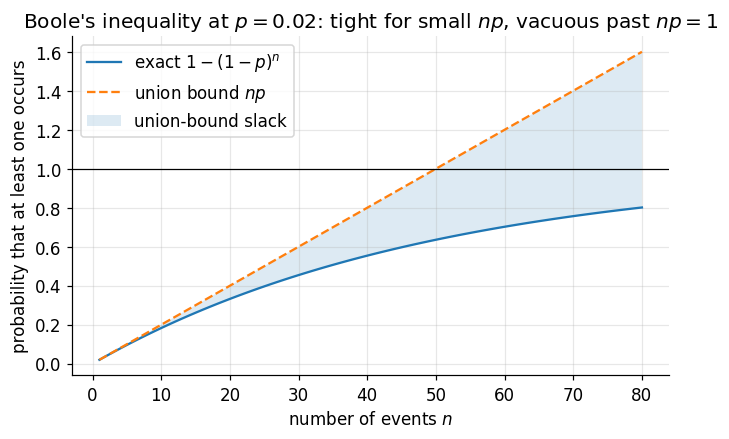

In [8]:
p_ev = 0.02
n_events = np.arange(1, 81)
exact_any = 1 - (1 - p_ev) ** n_events
boole = n_events * p_ev

assert np.all(exact_any <= boole + 1e-12), "union bound violated"
print("Boole's inequality holds for every n in 1..80")
for n in (1, 3, 10, 30, 50, 80):
    e, b = exact_any[n - 1], boole[n - 1]
    print(f"  n={n:>2}  exact={e:.6f}  bound={b:.6f}  ratio={b / e:.4f}")

fig, ax = plt.subplots()
ax.plot(n_events, exact_any, label=r"exact $1-(1-p)^n$")
ax.plot(n_events, boole, "--", label=r"union bound $np$")
ax.fill_between(n_events, exact_any, boole, alpha=0.15, label="union-bound slack")
ax.axhline(1.0, color="k", lw=0.8)
ax.set_xlabel("number of events $n$")
ax.set_ylabel("probability that at least one occurs")
ax.set_title(f"Boole's inequality at $p={p_ev}$: tight for small $np$, vacuous past $np=1$")
ax.legend()
plt.show()

At $n = 3$ the bound is 2.0% high; at $n = 30$ it is 32% high; at $n = 50$ it reaches exactly 1 while
the truth is $0.636$, and past that it says nothing at all — at $n = 80$ the bound is $1.6$ against a
true $0.801$. Theorem 4.4 is a tool for the rare-event regime $\sum_i \mathbb{P}(A_i) \ll 1$ and nothing else.

## 8. Applications

### 8.1 Physics

- **Statistical mechanics.** A microcanonical ensemble *is* Definition 3.6: $\Omega$ is the set of microstates of fixed energy, and the equal-weight assumption is the ergodic hypothesis. Boltzmann entropy $S = k_B \ln \lvert \Omega\rvert$ is a statement about the size of the sample space.
- **Quantum measurement.** For a fixed observable with eigenbasis $\{|a_i\rangle\}$, the Born rule $\mathbb{P}(a_i) = \lvert \langle a_i \mid \psi\rangle\rvert^2$ defines a probability measure on the spectrum: non-negativity is automatic from the modulus squared, and normalization is $\lVert \psi \rVert^2 = 1$ via Parseval. Kolmogorov's axioms hold *per observable*; they do not extend to a single joint measure over non-commuting observables, which is precisely the content of Bell's theorem.
- **Radioactive decay.** $\Omega = [0,\infty)$ with the Borel $\sigma$-algebra is the standard space for lifetimes, and continuity (Theorem 4.5) is what makes $\mathbb{P}(T \gt t)$ a well-defined right-continuous function of $t$.

### 8.2 Machine learning

- **Language models.** A next-token distribution is a probability measure on the finite space $\Omega = \{1,\ldots,V\}$ of vocabulary items; softmax enforces Axioms 1 and 2 structurally. Nucleus (top-$p$) sampling then conditions on a smallest high-probability set, which is Definition 3.4 restricted and renormalized.
- **Generalization bounds.** For a finite hypothesis class $\mathcal{H}$, PAC bounds read $\mathbb{P}(\exists h \in \mathcal{H} : \lvert \hat R(h) - R(h)\rvert \gt \epsilon) \le \lvert \mathcal{H}\rvert \, e^{-2n\epsilon^2}$ — Theorem 4.4 applied to $\lvert\mathcal{H}\rvert$ failure events, each bounded by Hoeffding's inequality. No independence between hypotheses is assumed, and none is available; that is exactly why the union bound is the right tool.
- **Multiple comparisons.** Evaluating $m$ model variants on one benchmark inflates the chance that some variant looks best by luck. Testing each at level $\alpha/m$ caps the family-wise error at $\alpha$ by Theorem 4.4, and Theorem 4.6 is the same statement about simultaneous confidence intervals.
- **Sampling algorithms.** Inverse-CDF sampling, rejection sampling, and alias tables are constructive implementations of a target measure; their correctness proofs are applications of Theorems 4.2 and 4.5.

## 9. Key Takeaways

1. On any probability space, $\mathbb{P}(\emptyset) = 0$ follows from Axiom 3 applied to $\emptyset,\emptyset,\ldots$ alone, and finite additivity follows only afterwards — the reverse order is circular (Lemma 4.1).
2. For any $A \in \mathcal{F}$, $\mathbb{P}(A^c) = 1 - \mathbb{P}(A)$ and $0 \le \mathbb{P}(A) \le 1$; the range $[0,1]$ is derived from Axioms 1–3, not assumed (Theorem 4.2).
3. If $A \subseteq B$ then $\mathbb{P}(B \setminus A) = \mathbb{P}(B) - \mathbb{P}(A)$ and $\mathbb{P}(A) \le \mathbb{P}(B)$; the containment hypothesis is essential, since $\mathbb{P}(B) - \mathbb{P}(A)$ can otherwise be negative (Theorem 4.2).
4. For finitely many arbitrary events, $\mathbb{P}(\bigcup_i A_i)$ equals the alternating sum over all $2^n - 1$ nonempty intersections — no disjointness, no independence, but $n$ must be finite (Theorem 4.3).
5. For any countable, arbitrarily dependent family, $\mathbb{P}(\bigcup_i A_i) \le \sum_i \mathbb{P}(A_i)$; the bound is tight when $\sum_i \mathbb{P}(A_i) \ll 1$ and vacuous once that sum exceeds 1 (Theorem 4.4).
6. If $A_n \uparrow A$ then $\mathbb{P}(A_n) \to \mathbb{P}(A)$, and if $B_n \downarrow B$ then $\mathbb{P}(B_n) \to \mathbb{P}(B)$; the decreasing half needs $\mathbb{P}(B_1) \lt \infty$, automatic for a probability measure but false for Lebesgue measure on $\mathbb{R}$ (Theorem 4.5).
7. For any $A_1,\ldots,A_n$, $\mathbb{P}(\bigcap_i A_i) \ge \sum_i \mathbb{P}(A_i) - (n-1)$, which is informative only when the events are individually near-certain (Theorem 4.6).
8. Countable additivity is strictly stronger than finite additivity: natural density on $\mathbb{N}$ satisfies Axioms 1 and 2 and is finitely additive, yet assigns $0$ to every singleton and $1$ to $\mathbb{N}$, so Theorem 4.5 fails for it (Section 7).

## 10. References

| Source | Chapters / sections | Coverage |
|---|---|---|
| Kolmogorov, *Foundations of the Theory of Probability* (1933) | Ch. I §§1–2, Ch. II §1 | The original axiomatization; the continuity axiom and its equivalence with countable additivity. |
| Blitzstein & Hwang, *Introduction to Probability*, 2nd ed. | Ch. 1 (§§1.2–1.6, Thm 1.6.2) | Naive definition, counting, story proofs, inclusion–exclusion. |
| Ross, *A First Course in Probability*, 10th ed. | Ch. 1; Ch. 2 (§§2.2–2.5, Prop. 4.4) | Combinatorial analysis; axioms and the derived propositions. |
| Casella & Berger, *Statistical Inference*, 2nd ed. | §§1.1–1.2 (Thm 1.2.8–1.2.11), §1.2.3 | Set theory, $\sigma$-algebras, Kolmogorov axioms, Bonferroni. |
| Wasserman, *All of Statistics* | Ch. 1 (§§1.2–1.5, Thm 1.8) | Compressed measure-free treatment aimed at ML readers. |
| Billingsley, *Probability and Measure*, 3rd ed. | §§1–3 (Thms 2.1, 3.1) | Non-measurable sets, Carathéodory extension, continuity theorems. |
| Bertsekas & Tsitsiklis, *Introduction to Probability*, 2nd ed. | Ch. 1 (§§1.1–1.2) | Probabilistic models and engineering examples. |

**Reading path.** Blitzstein & Hwang Ch. 1 for intuition, Casella & Berger §§1.1–1.2 for rigor at this level, Billingsley §§1–3 for the measure-theoretic completion (existence of Lebesgue measure, which this module assumes but does not construct).